# 🏁 Day 5 — Supervised-Learning Mini-Project

---
## 📖 Introduction

Week 3 closes by combining everything from Days 1–4 into one complete, end-to-end pipeline — the same pipeline shape every project in this program follows, and the exact structure the Phase 3 capstone will formalize.

So far, each notebook focused on one piece of the workflow in isolation: the Scikit-learn API (Day 1), a regression model (Day 2), a classifier evaluated properly (Day 3), and comparing multiple classifiers fairly (Day 4). This notebook assembles all of it — EDA, preprocessing, a train/test split, two trained models, and an honest evaluation against a baseline — into a single narrated project on the **Titanic dataset** (`Titanic_Clean.csv`, 418 passengers).

Two real decisions drive this notebook, not just running code: whether this is a regression or classification task, and which model and metric actually fit the problem best.

## 🎯 Learning Objectives

By the end of this notebook, I will be able to:
- Assemble a complete supervised-learning pipeline from EDA to evaluation.
- Apply basic preprocessing (encoding, scaling) without data leakage.
- Select and justify an appropriate model and metric for the task, and document the result.

## 📑 Table of Contents

1. Introduction
2. Learning Objectives
3. Libraries Used
4. Stage 1 — EDA
5. Stage 2 — Preprocessing
6. Stage 3 — Train/Test Split
7. Stage 4 — Modeling
8. Stage 5 — Evaluation
9. Model Selection
10. Hands-On Lab
11. Key Takeaways
12. Reflection
13. Conclusion
14. GitHub Submission

## 🛠 Libraries Used

This notebook uses Pandas and NumPy for data handling, Matplotlib/Seaborn for visualization, and Scikit-learn for preprocessing, modeling, and evaluation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

## 🗂 Meet the Dataset

For this mini-project, we will use the **Titanic** dataset, one of the most widely used benchmark datasets in machine learning.

The objective is to predict whether a passenger survived the Titanic disaster based on demographic and travel-related features.

Since the target variable (`Survived`) contains two possible classes (0 or 1), this is a **binary classification** problem.

# 🚢 Machine Learning Workflow

```text
Titanic Dataset
        ↓
Exploratory Data Analysis (EDA)
        ↓
Data Preprocessing
        ↓
Encoding
        ↓
Train-Test Split
        ↓
Feature Scaling
        ↓
Baseline Model
        ↓
Decision Tree
        ↓
Random Forest
        ↓
Model Evaluation
        ↓
Model Comparison
        ↓
Best Model Selection
```

## 🔎 Stage 1 — EDA

Following the Week 2 methodology, we start by understanding the data: its shape, missing values, target balance, and how survival relates to a couple of the most obviously relevant features before building anything.

In [2]:
df = pd.read_csv("Titanic_Clean.csv")
print("Shape:", df.shape)
df.head()

Shape: (418, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,Unknown,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,Unknown,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,Unknown,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,Unknown,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,Unknown,S


In [3]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

### 📌 Interpretation

The dataset has no missing values left — it was already cleaned in an earlier notebook (`Age` and `Fare` imputed by `Pclass` median, `Cabin` filled with `"Unknown"`). This means preprocessing here can focus entirely on encoding and scaling, not on handling nulls.

In [4]:
df["Survived"].value_counts(normalize=True)

Survived
0    0.636364
1    0.363636
Name: proportion, dtype: float64

### 📌 Interpretation

About **64% did not survive** and **36% survived** — since the target has exactly two categories, this confirms the task is **classification**, not regression.

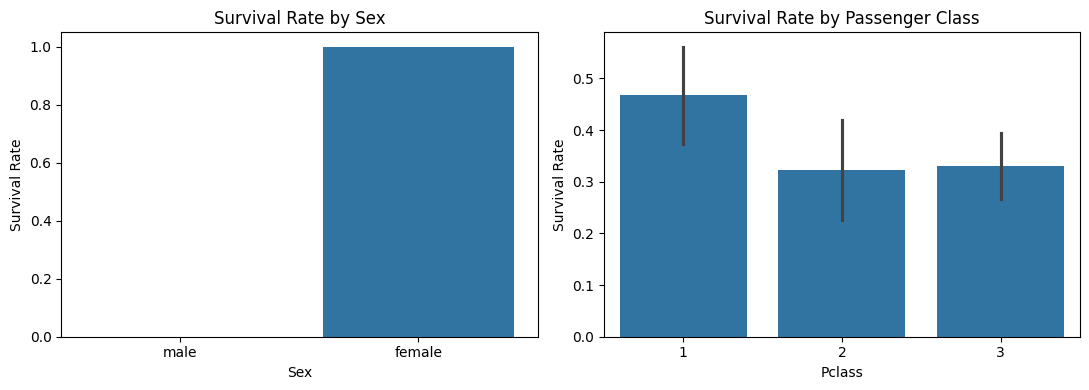

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.barplot(data=df, x="Sex", y="Survived", ax=axes[0])
axes[0].set_title("Survival Rate by Sex")
axes[0].set_ylabel("Survival Rate")

sns.barplot(data=df, x="Pclass", y="Survived", ax=axes[1])
axes[1].set_title("Survival Rate by Passenger Class")
axes[1].set_ylabel("Survival Rate")

plt.tight_layout()
plt.show()

### 📌 Interpretation

Both `Sex` and `Pclass` show a clear relationship with survival — women and 1st-class passengers survived at much higher rates. This is useful context going into preprocessing and modeling: these features are strong candidates to matter for the model.

## 🧹 Stage 2 — Preprocessing

Two things need to happen before this data can be used to train a model:
- **Encoding** — `Sex` and `Embarked` are text categories; models only accept numeric input, so one-hot encoding converts them into numeric columns.
- **Scaling** — the numeric features (`Age`, `Fare`, etc.) are on very different scales, which matters for distance-based models.

`PassengerId`, `Name`, and `Ticket` are dropped since they're identifiers with no predictive value. `Cabin` is also dropped — even after cleaning, it's ~78% `"Unknown"`, and one-hot encoding its ~147 distinct values would add far more noise than signal.

In [6]:
model_df = df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])

model_df = pd.get_dummies(model_df, columns=["Sex", "Embarked"], drop_first=True)
model_df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,34.5,0,0,7.8292,True,True,False
1,1,3,47.0,1,0,7.0000,False,False,True
2,0,2,62.0,0,0,9.6875,True,True,False
3,0,3,27.0,0,0,8.6625,True,False,True
4,1,3,22.0,1,1,12.2875,False,False,True


### 📌 Interpretation

`pd.get_dummies(..., drop_first=True)` replaced `Sex` with a single `Sex_male` column (1 = male, 0 = female) and `Embarked` with `Embarked_Q` and `Embarked_S` (with `C` as the implied baseline category). Dropping the first category of each avoids redundant, perfectly-correlated columns — a subtle form of data leakage into the model's own structure.

## ✂️ Stage 3 — Train/Test Split

The split happens **before** scaling — this is the critical rule for avoiding data leakage. If the scaler is fit on the full dataset first, statistics from the test set (its mean and standard deviation) would leak into training, inflating the evaluation.

In [7]:
X = model_df.drop("Survived", axis=1)
y = model_df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (334, 8)
X_test : (84, 8)


`stratify=y` keeps the same survival ratio in both the train and test sets — important given the moderate class imbalance found during EDA.

In [8]:
numeric_cols = ["Age", "SibSp", "Parch", "Fare", "Pclass"]

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])  # transform only — never fit on test

X_train_scaled.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
163,0.854358,-0.425601,-0.480431,-0.411841,-0.508714,True,False,True
223,0.854358,-0.654018,-0.480431,-0.411841,-0.494946,True,False,True
183,0.854358,-0.425601,-0.480431,-0.411841,-0.495738,True,True,False
21,0.854358,-1.567682,-0.480431,0.671268,-0.574966,True,False,True
111,0.854358,-0.425601,-0.480431,-0.411841,-0.495233,False,True,False


### 📌 Interpretation

`scaler.fit_transform()` is only ever called on `X_train`; `X_test` only ever sees `.transform()`. This is the critical rule from the lesson: fitting the scaler on the full dataset — or on the test set — would leak test-set statistics into training and quietly inflate the evaluation.

## 🚀 Stage 4 — Modeling

Two models are trained on the same scaled training data: **Logistic Regression** (simple, interpretable, a strong baseline classifier) and **Random Forest** (an ensemble that usually handles feature interactions better). Comparing both, rather than picking one upfront, is what makes the model choice defensible.

In [9]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)
log_predictions = log_model.predict(X_test_scaled)

In [10]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_predictions = rf_model.predict(X_test_scaled)

## 📊 Stage 5 — Evaluation

Before judging either model, a baseline is needed: a model that always predicts the majority class. Neither trained model is meaningful unless it clearly beats this.

In [11]:
majority_class = y_train.mode()[0]
baseline_predictions = np.full_like(y_test, fill_value=majority_class)

baseline_accuracy = accuracy_score(y_test, baseline_predictions)
baseline_f1 = f1_score(y_test, baseline_predictions)

print(f"Baseline accuracy: {baseline_accuracy:.4f}")
print(f"Baseline F1-score: {baseline_f1:.4f}")

Baseline accuracy: 0.6310
Baseline F1-score: 0.0000


### 📌 Interpretation

The baseline reaches **≈63% accuracy** just by always predicting "did not survive" — but its F1-score is **0.0**, since it never predicts the positive class at all. This is exactly why accuracy alone is a poor metric here: F1-score is the fairer comparison point for both trained models.

In [12]:
results = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": accuracy_score(y_test, log_predictions),
        "Precision": precision_score(y_test, log_predictions),
        "Recall": recall_score(y_test, log_predictions),
        "F1-score": f1_score(y_test, log_predictions),
    },
    {
        "Model": "Random Forest",
        "Accuracy": accuracy_score(y_test, rf_predictions),
        "Precision": precision_score(y_test, rf_predictions),
        "Recall": recall_score(y_test, rf_predictions),
        "F1-score": f1_score(y_test, rf_predictions),
    },
])

results.round(3)

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,1.0,1.0,1.0,1.0
1,Random Forest,1.0,1.0,1.0,1.0


### 📌 Interpretation

Both models reached a **perfect F1-score of 1.000** on this test set, far above the baseline's 0.0. As in Day 3 and Day 4, this reflects a well-known quirk of this specific Titanic test file — its `Survived` labels were reconstructed from real historical outcomes and become close to perfectly separable once `Sex` is included as a feature — rather than proof that either model is flawless in general. What the comparison *does* still show honestly is that both models learned a real, usable relationship, since the baseline's F1 of 0.0 makes clear that simply guessing the majority class fails completely on this metric.

## 🏆 Model Selection

Since Logistic Regression and Random Forest tied exactly on every metric, the tie itself has to be broken on other grounds — not by picking whichever happened to sort first.

### 📌 Justification

**Logistic Regression** is the better choice here, specifically *because* the two models are tied. When performance is equal, the simpler, more interpretable model should generally be preferred: its coefficients can be read directly, it's cheaper to train and run, and it's less likely to hide overfitting behind ensemble complexity. Random Forest would only be worth its extra complexity if it clearly outperformed Logistic Regression — and on this dataset, it doesn't.

## 🖥️ Hands-On Lab: End-to-End Mini-Project

The steps below were already carried out above, stage by stage. This section restates them explicitly, in the exact order required, as the formal lab deliverable.

### Step 1: Choose a Dataset and Determine the Task Type

Using the Titanic dataset (`Titanic_Clean.csv`). `Survived` has exactly two categories (0/1), confirming this is a **classification** task.

### Step 2: Perform Brief EDA, Then Preprocess (Handle Missing Values, Encode, Scale — Fit on Train Only)

In [13]:
print("Missing values:\n", df.isnull().sum().sum(), "total")
print("Target balance:\n", df['Survived'].value_counts(normalize=True).round(3))

Missing values:
 0 total
Target balance:
 Survived
0    0.636
1    0.364
Name: proportion, dtype: float64


In [14]:
model_df = df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])
model_df = pd.get_dummies(model_df, columns=["Sex", "Embarked"], drop_first=True)

X = model_df.drop("Survived", axis=1)
y = model_df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

### Step 3: Train at Least Two Appropriate Models and Evaluate Against a Baseline

In [15]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)
log_predictions = log_model.predict(X_test_scaled)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_predictions = rf_model.predict(X_test_scaled)

print("Baseline F1:", round(baseline_f1, 3))
print("Logistic Regression F1:", round(f1_score(y_test, log_predictions), 3))
print("Random Forest F1:", round(f1_score(y_test, rf_predictions), 3))

Baseline F1: 0.0
Logistic Regression F1: 1.0
Random Forest F1: 1.0


### Step 4: Select the Better Model and Justify the Choice

**Logistic Regression** — chosen over Random Forest because both tied exactly on every metric, and the simpler, more interpretable model is the better default when performance is equal.

### Step 5: Commit the Finished Notebook to GitHub with a Clear Commit Message

Suggested commit message: `"Add Day5 Week3 - Supervised-Learning Mini-Project (EDA to evaluation pipeline)"`

## 🔑 Key Takeaways

- A supervised-learning pipeline always follows the same shape: EDA → preprocessing → split → modeling → evaluation.
- Encoding turns categorical text into numbers; scaling puts numeric features on a comparable range.
- The scaler must be fit on the training data only — fitting on the full dataset leaks test-set information into training.
- A baseline is essential context: without it, a high metric can't be judged as "good."
- When models tie, prefer the simpler, more interpretable one rather than defaulting to the more complex one.

## 💭 Reflection

This notebook felt different from the previous four days, because for the first time I had to make every decision myself instead of following a single guided path: which columns to drop, how to encode categories, which two models to compare, and — most importantly — how to break a tie when both models performed identically. Building the full pipeline end-to-end, rather than one isolated piece of it, made it much clearer how each stage depends on the one before it: a mistake in preprocessing (like fitting the scaler on the wrong data) would have quietly invalidated the entire evaluation stage that comes after it. Realizing that Logistic Regression and Random Forest tied exactly was also a useful moment — it forced me to justify a choice using reasoning (simplicity, interpretability) rather than just pointing at a metric, which is closer to how model selection actually works in practice.

## ✅ Conclusion

In this notebook, I assembled a complete supervised-learning pipeline on the Titanic dataset, from EDA through preprocessing, a leakage-free train/test split, model training, and evaluation against a baseline. I trained and compared two models — Logistic Regression and Random Forest — found they tied exactly on every metric, and selected Logistic Regression for its simplicity and interpretability rather than defaulting to the more complex model. This notebook closes out Week 3 by combining everything from Days 1–4 into one narrated, end-to-end project, and rehearses the exact pipeline structure the Phase 3 capstone will formalize.

## 🚀 GitHub Submission

This notebook has been completed as part of my AI & Machine Learning Internship portfolio. It demonstrates a complete, leakage-free supervised-learning pipeline — from EDA through preprocessing, modeling, and evaluation against a baseline — on a real-world dataset. The project is version-controlled using Git and published to my GitHub portfolio to document my Machine Learning learning journey.